# CS+ Social Good Data Science Pipeline Workshop

In this workshop, we will explore the question:

**How well was the "Women and Children First" rule upheld on the Titanic?**

We will use Python and pandas to walk through the main steps of a beginner-friendly data science pipeline.

In [36]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

print(sys.executable)
print("Environment working! We can begin the Worskop!")

c:\Users\Admin\OneDrive\Desktop\CSSG\Intro_to_DataScience_TEA++\cssg-data-science-pipeline-workshop\.venv\Scripts\python.exe
Environment working! We can begin the Worskop!


## Step 1 - Define the Question

Before analyzing data, we need to clearly define our research question.

**How well was the "Women and Children First" rule upheld?**

To investigate this, we will compare survival outcomes across three groups:

- Children
- Women
- Adult Men

We define:

- **Child** as a passenger under age 18
- **Woman** as a female passenger age 18 or older.
- **Adult Man** as a male passenger age 18 or older.

With this, each passenger will belong to exactly one group.

## Step 2 - Load and Inspect the Data

Before analyzing anything, we first need to understand what data we have.

We will load the Titanic dataset using pandas.


In [37]:
df = pd.read_csv("../data/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Time to take a look at the dataset structure.

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [39]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [40]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Step 3 - Clean the Data

Before analyzing the data, we need to make sure that the impportant variables are usable.

For our purposes, we only care about:
1. Age
2. Sex
3. Survived

If any of those values are missing, we can't correctly classify the passenger or determine the outcome.

So here we will remove rows that are missing these values.

In [41]:
df_clean = df.dropna(subset=["Age", "Sex", "Survived"]).copy()

df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Why .copy() is important
.copy() prevents warnings/bugs when modifying the dataset.

In [42]:
print("Original number of rows:", len(df))
print("Number of rows after cleaning:", len(df_clean))

Original number of rows: 891
Number of rows after cleaning: 714


In [43]:
print("Missing Values After Cleaning:")

df_clean.isnull().sum()

Missing Values After Cleaning:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         2
dtype: int64

## Step 4 - Define Comparison Groups

Now that the data is clean, we need to classify each passenger into a group.

We will create three groups:

- Child
- Women
- Adult Man

For this workshop, we define:

- **Child** as a passenger under 18
- **Women** as a female passenger age 18 or older
- **Adult Man** as a male passenger age 18 or older

Each passenger will belong to exactly one group.

In [44]:
def classify_passenger(row):
    if row["Age"] < 18:
        return "Child"
    elif row["Sex"] == "female":
        return "Woman"
    else:
        return "Adult Man"

In [45]:
df_clean["group"] = df_clean.apply(classify_passenger, axis=1)

df_clean[["Age", "Sex" ,"group"]].head()

,Age,Sex,group
0,22.0,male,Adult Man
1,38.0,female,Woman
2,26.0,female,Woman
3,35.0,female,Woman
4,35.0,male,Adult Man


In [46]:
df_clean["group"].value_counts()

group
Adult Man    395
Woman        206
Child        113
Name: count, dtype: int64

In [47]:
df_clean["group"].isnull().sum()

np.int64(0)

## Step 5 - Analyze Survival Outcomes

Now that each passenger has been assigned to a group, we can compaer survival outcomes across those groups.

We will calculate:
- The number of survivors in each group
- The total number of passengers in each group
- The survival rate for each group

This will help us evaluate whether women and children had a survival advantage compared to adult men.

In [48]:
survival_counts = df_clean.groupby(["group", "Survived"]).size().unstack(fill_value=0)

survival_counts

Survived,0,1
group,,
Adult Man,325,70
Child,52,61
Woman,47,159


In [49]:
group_totals = df_clean["group"].value_counts()

group_totals

group
Adult Man    395
Woman        206
Child        113
Name: count, dtype: int64

In [50]:
survival_rates = df_clean.groupby("group")["Survived"].mean().sort_values(ascending=False)

survival_rates

group
Woman        0.771845
Child        0.539823
Adult Man    0.177215
Name: Survived, dtype: float64

In [51]:
survival_rates_percent = survival_rates * 100

survival_rates_percent

group
Woman        77.184466
Child        53.982301
Adult Man    17.721519
Name: Survived, dtype: float64

## Step 6 - Visualize Results

Numbers are useful, but actual visualizations make the patters we noted easier to understand.

To do this, we will create a bar chart showng the survival rate for each group:
- Child
- Woman
- Adult Man

This will help us quickly compare survival outcomes across groups.

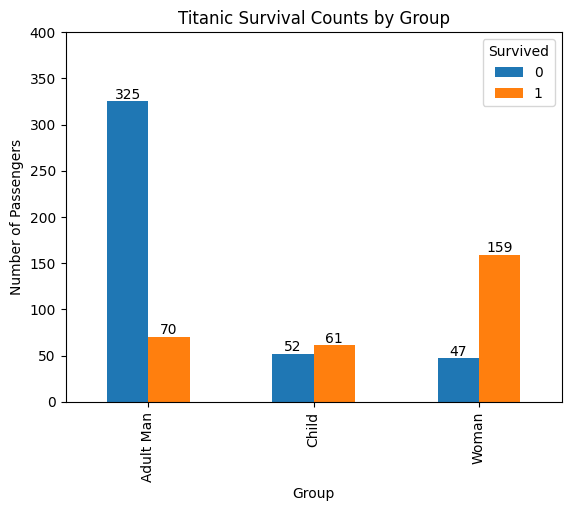

In [57]:
axes = survival_counts.plot(kind="bar")

plt.title("Titanic Survival Counts by Group")
plt.xlabel("Group")
plt.ylabel("Number of Passengers")
plt.ylim(0, 400)

# Add counts above each bar
for container in axes.containers:
    axes.bar_label(container)

plt.show()